# Step 1 – Data exploration

**Goal:** understand the EuroSAT RGB dataset before building any model.

**Questions:**
1. How many images are there, and how are they spread over the classes?
2. What do the images look like, and how hard does the task appear?
3. Are there simple signals (such as colour) that separate the classes?
4. How do we split the data so that the final evaluation is fair?

Dataset: *EuroSAT* (Helber et al., 2019), 27,000 Sentinel-2 satellite tiles, 64 × 64 px, 10 m per pixel, 10 land-use classes. See `docs/DATASET.md` for the source, licence and why it was chosen.

In [ ]:
# Setup: make the project package importable and fix random seeds
import sys, os
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from eurosat_cnn.config import CLASSES, DATA_DIR, MODELS_DIR, REPORTS_DIR, FIGURES_DIR, SEED
keras.utils.set_random_seed(SEED)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Keras", keras.__version__, "| data folder:", DATA_DIR)

## 1.1 Load the file list

In [ ]:
from eurosat_cnn.data import list_images

paths, labels = list_images(DATA_DIR)
print(f"{len(paths):,} images found")
df = pd.DataFrame({"path": paths, "label": [CLASSES[i] for i in labels]})
df.head()

27,000 images found


## 1.2 Class balance

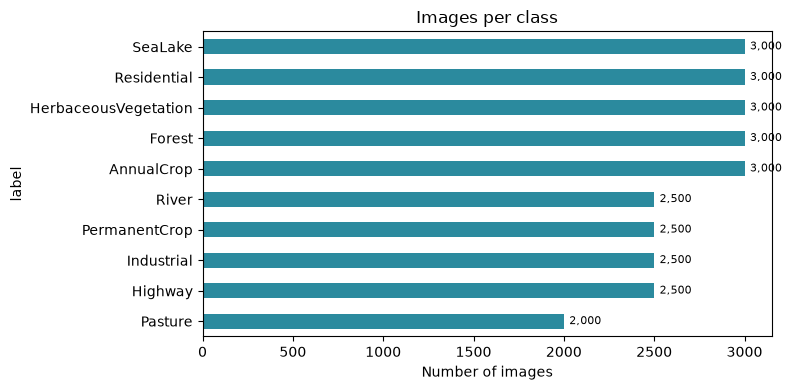

Largest / smallest class: 1.50


In [3]:
counts = df["label"].value_counts().reindex(CLASSES)
ax = counts.sort_values().plot.barh(figsize=(8, 4), color="#2b8a9e")
ax.set(xlabel="Number of images", title="Images per class")
for i, v in enumerate(counts.sort_values()):
    ax.text(v + 30, i, f"{v:,}", va="center", fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=150); plt.show()
print(f"Largest / smallest class: {counts.max() / counts.min():.2f}")

## 1.3 Look at the images

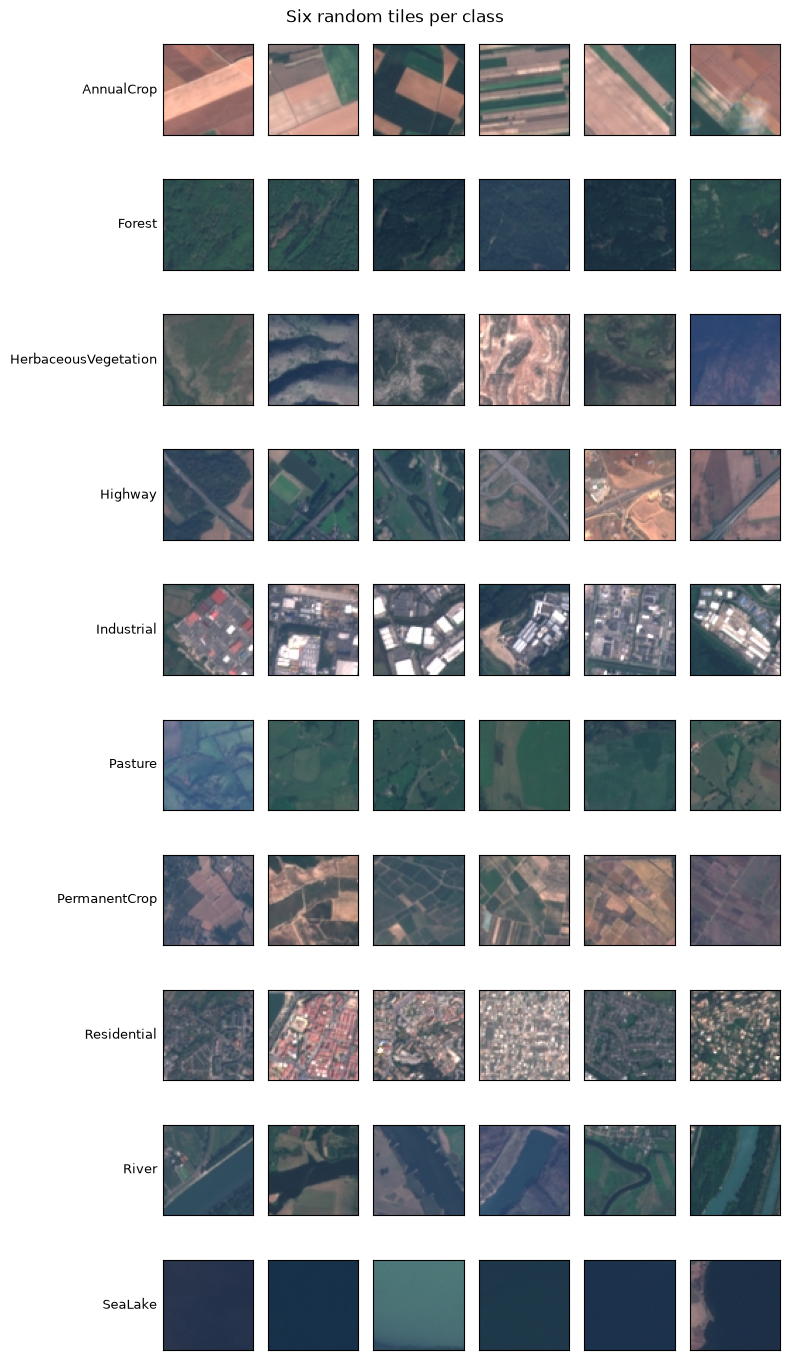

In [4]:
from PIL import Image

rng = np.random.default_rng(1)
fig, axes = plt.subplots(len(CLASSES), 6, figsize=(8, 14))
for r, name in enumerate(CLASSES):
    for c, p in enumerate(rng.choice(df.loc[df.label == name, "path"], 6, replace=False)):
        axes[r, c].imshow(Image.open(p)); axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[r, 0].set_ylabel(name, rotation=0, ha="right", va="center", fontsize=9)
plt.suptitle("Six random tiles per class"); plt.tight_layout()
plt.savefig(FIGURES_DIR / "sample_grid.png", dpi=150); plt.show()

## 1.4 Image format check

In [5]:
sizes = {Image.open(p).size for p in rng.choice(paths, 500, replace=False)}
modes = {Image.open(p).mode for p in rng.choice(paths, 500, replace=False)}
print("Image sizes found:", sizes, "| colour modes:", modes)

Image sizes found: {(64, 64)} | colour modes: {'RGB'}


## 1.5 Average colour per class
A quick check of how much information is in colour alone.

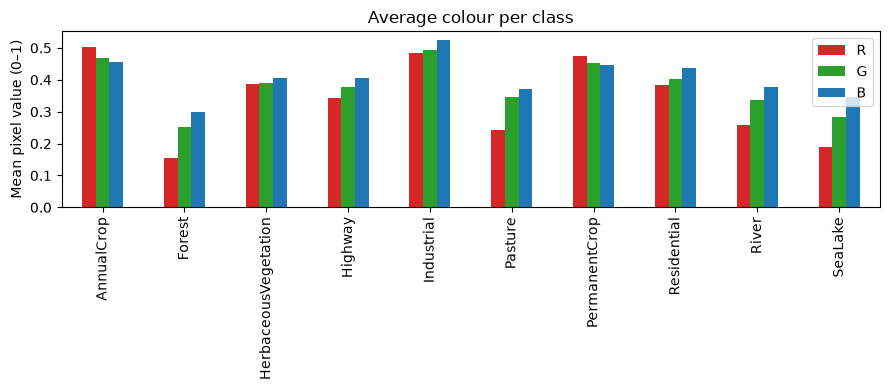

,R,G,B
AnnualCrop,0.503,0.468,0.457
Forest,0.154,0.252,0.299
HerbaceousVegetation,0.388,0.389,0.407
Highway,0.344,0.377,0.406
Industrial,0.485,0.493,0.526
Pasture,0.242,0.346,0.371
PermanentCrop,0.475,0.454,0.447
Residential,0.385,0.401,0.436
River,0.259,0.337,0.378
SeaLake,0.189,0.285,0.347


In [6]:
means = {}
for name in CLASSES:
    sample = rng.choice(df.loc[df.label == name, "path"], 300, replace=False)
    means[name] = np.stack([np.asarray(Image.open(p), dtype=np.float32) for p in sample]).mean(axis=(0, 1, 2)) / 255
mean_df = pd.DataFrame(means, index=["R", "G", "B"]).T
ax = mean_df.plot.bar(figsize=(9, 4), color=["#d62728", "#2ca02c", "#1f77b4"])
ax.set(ylabel="Mean pixel value (0–1)", title="Average colour per class")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "mean_colour_per_class.png", dpi=150); plt.show()
mean_df.round(3)

## 1.6 Train / validation / test split
70 % training, 15 % validation (model selection), 15 % test (used only once, at the very end). The split is stratified and seeded, so it is identical in every notebook and script.

In [7]:
from eurosat_cnn.data import stratified_split

train, val, test = stratified_split(paths, labels)
split_df = pd.DataFrame({
    "train": np.bincount(train.labels, minlength=10),
    "validation": np.bincount(val.labels, minlength=10),
    "test": np.bincount(test.labels, minlength=10),
}, index=CLASSES)
split_df.loc["TOTAL"] = split_df.sum()
split_df

,train,validation,test
AnnualCrop,2100,450,450
Forest,2100,450,450
HerbaceousVegetation,2099,451,450
Highway,1750,375,375
Industrial,1750,375,375
Pasture,1400,300,300
PermanentCrop,1750,375,375
Residential,2100,450,450
River,1750,375,375
SeaLake,2100,450,450


In [8]:
# Every class should have the same share in every split
shares = split_df.drop("TOTAL") / split_df.drop("TOTAL").sum()
print("Max difference in class share between splits:", float((shares.max(axis=1) - shares.min(axis=1)).max()).__round__(4))

Max difference in class share between splits: 0.0003


## 📝 Observations
*Write your own conclusions here after running the notebook. Points to cover:*
- Class balance: is accuracy a fair metric here?
- Which classes look easy, and which look similar to each other?
- What does the colour analysis suggest? Is colour alone enough?
- Why does a stratified, fixed split matter for this project?